### FONÉTICA
#### 1. Con base en el sistema de búsqueda visto en la práctica 1, dónde se recibe una palabra ortográfica y devuelve sus transcripciones fonológicas, proponga una solución para los casos en que la palabra buscada no se encuentra en el lexicón/diccionario.
##### *¿Cómo devolver o aproximar su transcripción fonológica?
A mi se me ocurrió una forma, la de analizar y relacionar ciertos tipos de sílabas o letras conocidas y colocar como definición su fonema si es que existe, así podríamos acercarnos a el sonido fonético real, creo que es una solución rápida y un poco simple pero que podría apoyarnos en la obtención de palabras con sílabas pocos comunes o nuevas que no se encuentren en el corpus o API seleccionado por.

Esta idea nació tras experimentar por un par de días con ciertas palabras que descubrí no están dentro del API que usamos de ejemplo en clase, palabras como luis o francisco palabras comunes de nombres propios para nosotros, sin embargo conteniendo palabras como ñoño o luís (si, con acento).

Por ejemplo, si queremos que tenga palabras no existentes en el corpus podríamos indicar que siempre de la forma fonética de las letras para que cualquier palabra pueda ser escrita en base a las reglas de la fonética y pronunciación de nuestro idioma para cada vocal y consonante construyendo una aproximación, o si encuentra similitiudes que arroje una palabra similar y las correlacione
##### *Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad.
Los ejemplos utilizados serán:

Luis

Francisco

frijol

 La forma de usarlo es tal cual en clase corriendo el programa y colocando el tipo de lenguaje que queremos seguido de la palabra.

In [143]:
import http
from collections import defaultdict
import difflib # Cambio propuesto: Se añade la librería difflib para la aproximación de palabras.

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text #Estás son las librerias y funciones necesarias ya definidas que iremos usando

In [144]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"
#Exportamos el ipa que vimos en clase

In [145]:
#Empezamos con las definiciones como en clase
response = r.get(IPA_URL.format(lang="es_MX"))
ipa_list = response.text[:1000].split("\n")
ipa_list[-1].split("\t")

['ababillaréis', '/aβaβiʎaˈɾe']

In [146]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict

    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any, (e.g., ['/transcription1/', '/transcription2/'])
        else a list containing an empty string, [''], if not found.
    """
    # Cambio propuesto: la función ahora devolverá [''] si la palabra no se encuentra
    # para permitir que la función de aproximación actúe en el caso OOV.
    result = dataset.get(word.lower(), "")
    if result == "":
        return ['']
    return result.split(", ")

def obtener_fonologia_aproximada(palabra_buscada: str, lexico: dict) -> list[str]:
    """Propone una transcripción fonológica aproximada para palabras OOV (Out-Of-Vocabulary).

    Utiliza difflib para encontrar la palabra más cercana en el lexicón y devuelve su transcripción.

    Parameters:
    -----------
    palabra_buscada: str
        La palabra a buscar.
    lexico: dict
        El diccionario fonético (corpus).

    Returns:
    --------
    list[str]:
        Una lista con la transcripción aproximada o un mensaje de error.
    """
    # Se busca la coincidencia más cercana en el lexicón, normalizando a minúsculas.
    similares = difflib.get_close_matches(palabra_buscada.lower(), lexico.keys(), n=1, cutoff=0.6)

    if similares:
        palabra_aproximada = similares[0]
        rprint(f"⚠️ '[yellow]{palabra_buscada}[/]' no encontrada. Aproximando a: '[green]{palabra_aproximada}[/]'")
        # Se devuelve la transcripción de la palabra aproximada como una lista.
        return [lexico[palabra_aproximada]]
    else:
        # Si no se encuentra ninguna aproximación, se devuelve un mensaje de error como una lista.
        return [f"❌ No se encontró '{palabra_buscada}' ni ninguna aproximación."]

In [147]:
def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github

    Parameters:
    -----------
    iso_lang:
        Language as iso code

    Results:
    --------
    dict:
        Dictionary with words as keys and phonetic representation
        as values for a given lang code
    """
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

In [148]:
def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict

    Each row have the format:
    [WORD][TAB]/[IPA]/(, /[IPA]/)?

    Parameters
    ----------
    response: str
        ipa-dict raw text

    Returns
    -------
    dict:
        A dictionary with the word as key and the phonetic
        representations as value
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result


In [149]:
lang_codes = {
    "es_ES": "Spanish (Spain)",
    "es_MX": "Spanish (Mexico)",#En mi caso decidi reducirlo a español tanto europeo como mexicano
}
iso_lang_codes = list(lang_codes.keys())

def get_corpora() -> dict:
    """Download corpora from ipa-dict github

    Given a list of iso lang codes download available datasets.

    Returns
    -------
    dict
        Lang codes as keys and dictionary with words-transcriptions
        as values
    """
    return {
        code: parse_response(download_ipa_corpus(code))
         for code in iso_lang_codes
        }

corpora = get_corpora()

In [150]:
def get_formated_string(code: str, name: str):
    return f"[b]{name}[/b]\n[yellow]{code}"

In [151]:
import http
from collections import defaultdict
import difflib # Cambio propuesto: Se añade la librería difflib para la aproximación de palabras.

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text #Estás son las librerias y funciones necesarias ya definidas que iremos usando

In [152]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict

    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any, (e.g., ['/transcription1/', '/transcription2/'])
        else a list containing an empty string, [''], if not found.
    """
    # Cambio propuesto: la función ahora devolverá [''] si la palabra no se encuentra
    # para permitir que la función de aproximación actúe en el caso OOV.
    result = dataset.get(word.lower(), "")
    if result == "":
        return ['']
    return result.split(", ")

def obtener_fonologia_aproximada(palabra_buscada: str, lexico: dict) -> list[str]:
    """Propone una transcripción fonológica aproximada para palabras OOV (Out-Of-Vocabulary).

    Utiliza difflib para encontrar la palabra más cercana en el lexicón y devuelve su transcripción.

    Parameters:
    -----------
    palabra_buscada: str
        La palabra a buscar.
    lexico: dict
        El diccionario fonético (corpus).

    Returns:
    --------
    list[str]:
        Una lista con la transcripción aproximada o un mensaje de error.
    """
    # Se busca la coincidencia más cercana en el lexicón, normalizando a minúsculas.
    similares = difflib.get_close_matches(palabra_buscada.lower(), lexico.keys(), n=1, cutoff=0.6)

    if similares:
        palabra_aproximada = similares[0]
        rprint(f"⚠️ '[yellow]{palabra_buscada}[/]' no encontrada. Aproximando a: '[green]{palabra_aproximada}[/]'")
        # Se devuelve la transcripción de la palabra aproximada como una lista.
        return [lexico[palabra_aproximada]]
    else:
        # Si no se encuentra ninguna aproximación, se devuelve un mensaje de error como una lista.
        return [f"❌ No se encontró '{palabra_buscada}' ni ninguna aproximación."]

In [156]:
rprint(
    Panel(Text("Representación fonética de palabras", style="bold", justify="center"))
)
rendable_langs = [
    Panel(get_formated_string(code, lang), expand=True)
    for code, lang in lang_codes.items()
]
rprint(Columns(rendable_langs))

lang = input("lang>> ")
rprint(f"Selected language: {lang_codes[lang]}") if lang else rprint("Adios 👋🏼")
while lang:
    dataset = corpora[lang]
    query = input(f"  [{lang}]word>> ")
    results = get_ipa_transcriptions(query, dataset)
    # Cambio propuesto: Si get_ipa_transcriptions devuelve [''] (palabra no encontrada directamente),
    # se intenta obtener una aproximación fonológica.
    if results == ['']:
        results = obtener_fonologia_aproximada(query, dataset)
    rprint(query, " | ", ", ".join(results))
    while query:
        query = input(f"  [{lang}]word>> ")
        if query:
            results = get_ipa_transcriptions(query, dataset)
            # Cambio propuesto: Misma lógica de aproximación para consultas subsiguientes.
            if results == ['']:
                results = obtener_fonologia_aproximada(query, dataset)
            rprint(query, " | ", ", ".join(results))
    lang = input("lang>> ")
    rprint(f"Selected language: [yellow]{lang_codes[lang]}[/]") if lang else rprint(
        "Adios 👋🏼"
    )

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                       Representación fonética de palabras                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────╮ ╭──────────────────╮
│ Spanish (Spain) │ │ Spanish (Mexico) │
│ es_ES           │ │ es_MX            │
╰─────────────────╯ ╰──────────────────╯

lang>> es_MX


Selected language: Spanish (Mexico)

  [es_MX]word>> Luis


...

  [es_MX]word>> frijol


⚠️ 'frijol' no encontrada. Aproximando a: 'fréjol'

frijol  |  /ˈfɾexol/

  [es_MX]word>> 
lang>> 


Adios 👋🏼

### Morfología
#### 2.Elige tres lenguas del corpus que pertenezcan a familias lingüísticas distintas
Ejemplo: spa (Romance), eng (Germánica), hun (Urálica)
Para cada una de las tres lenguas calcula y compara:
Ratio morfemas / palabra: El promedio de morfemas que componen las palabras
Indicé de Flexión / Derivación: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (100) y cuáles de derivación (010)?
#### 3.Visualización
Genera una figura con subplots para comparar las lenguas lado a lado.
Plot 1: Distribución de la longitud de los morfemas
Plot 2: Distribución de las categorías (flexión, derivación, raíz, etc.)
#### 4Con base en esta información, responde la pregunta: ¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?
Justifica tu respuesta usando tus métricas y figuras

In [2]:
# !uv add nltk scikit-learn sklearn-crfsuite <- Local con uv
!pip install nltk scikit-learn sklearn-crfsuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.7 MB/s eta 0:00:00


In [3]:
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import requests as r
from nltk.corpus import cess_esp

from rich import print as rprint

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF

In [4]:
response = r.get("https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/spa.word.test.gold.tsv")
word_list = response.text[:1000].split("\n")
word_list[0].split("\t")

['astronómica', 'astronómico @@a', '100']

In [5]:
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task

    Con base en el idioma y el track obtiene el nombre de los archivos
    para con información reelevante para hacer análisis estadístico.
    Esto es archivos .test y .dev

    Parameters:
    ----------
    lang : str
        Idioma para el cual se generarán los nombres de archivo.
    track : str, optional
        Track del shared task de donde vienen los datos (por defecto es "word").

    Returns:
    -------
    list[str]
        Una lista de nombres de archivo generados para el idioma y la pista especificados.
    """
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]


In [6]:
def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde una URL base.

    Parameters:
    ----------
    files : list
        Lista de nombres de archivos (sin extensión) que se descargarán
        y concatenarán.

    Returns:
    -------
    list
        Una lista que contiene los contenidos descargados y concatenados
        de los archivos tsv.
    """
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

In [7]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame

    Parameters:
    ----------
    corpus_list : list
        Lista de líneas del corpus a convertir en DataFrame.
    lang : str
        Idioma al que pertenecen los datos del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

In [134]:
def percentage_morpheme_types(df: pd.DataFrame, lang:str):
    """Calcula y obtiene los porcentajes de cuales son de flexión o derivación
    """
    totalcounts = "morph_count"
    total_morphemes = df[totalcounts].sum()
    inflection = df[df['category']=='100'][totalcounts].sum()
    percent_inflection = (inflection/total_morphemes)*100 if total_morphemes > 0 else 0
    derivation = df[df['category']=='010'][totalcounts].sum()
    percent_derivation = (derivation/total_morphemes)*100 if total_morphemes > 0 else 0
    print(f"\n--- {lang} ---")
    print(f"Número total de morfemas: {total_morphemes}")
    print(f"Morfemas de flexión ('100'): {inflection} ({percent_inflection:.2f}%)")
    print(f"Morfemas de derivación ('010'): {derivation} ({percent_derivation:.2f}%) ")


In [138]:
files_spa = get_track_files("spa")
raw_spa = get_raw_corpus(files_spa)
df_spa = raw_corpus_to_dataframe(raw_spa, lang="spa")
print(df_spa.head())
morphemes_per_word_ratio_spa = df_spa['morph_count'].mean()
print(f"El número promedio de morfemas por palabra para español es: {morphemes_per_word_ratio_spa:.2f}")
df_spa["category"].value_counts().head(30)
morph_percentses = percentage_morpheme_types(df_spa,"Español")
print(morph_percentses)

             words                        morph category lang  word_len  \
0      astronómica           [astronómico, @@a]      100  spa        11   
1    resignifiques         [resignificar, @@es]      100  spa        13   
2   importunamente         [importuno, @@mente]      010  spa        14   
3  conjeturaríamos  [conjeturar, @@ría, @@amos]      100  spa        15   
4       adquiridla       [adquirir, @@id, @@la]      100  spa        10   

   morph_count  
0            2  
1            2  
2            2  
3            3  
4            3  
El número promedio de morfemas por palabra para español es: 3.24

--- Español ---
Número total de morfemas: 557191
Morfemas de flexión ('100'): 220672 (39.60%)
Morfemas de derivación ('010'): 13327 (2.39%) 
None


In [139]:
files_rus = get_track_files("rus")
raw_rus = get_raw_corpus(files_rus)
df_rus = raw_corpus_to_dataframe(raw_rus, lang="rus")
print(df_rus.head())
morphemes_per_word_ratio_rus = df_rus['morph_count'].mean()
print(f"El número promedio de morfemas por palabra para ruso es: {morphemes_per_word_ratio_rus:.2f}")
df_rus["category"].value_counts().head(30)

morph_percentsrus = percentage_morpheme_types(df_spa,"Ruso")
print(morph_percentsrus)


            words                                    morph category lang  \
0  арестовывавшую  [арест, @@овать, @@ывать, @@вший, @@ую]      110  rus   
1      духовников                         [духовник, @@ов]      100  rus   
2        передачу                [пере, @@дать, @@ча, @@у]      110  rus   
3    прижавшегося       [при, @@жать, @@вший, @@его, @@ся]      110  rus   
4   аннексированы       [аннексия, @@ировать, @@нный, @@ы]      110  rus   

   word_len  morph_count  
0        14            5  
1        10            2  
2         8            4  
3        12            5  
4        13            4  
El número promedio de morfemas por palabra para ruso es: 3.85

--- Ruso ---
Número total de morfemas: 557191
Morfemas de flexión ('100'): 220672 (39.60%)
Morfemas de derivación ('010'): 13327 (2.39%) 
None


In [140]:
files_hun = get_track_files("hun")
raw_hun = get_raw_corpus(files_hun)
df_hun = raw_corpus_to_dataframe(raw_hun, lang="hun")
print(df_hun.head())
morphemes_per_word_ratio_hun = df_hun['morph_count'].mean()
print(f"El número promedio de morfemas por palabra para húngaro es: {morphemes_per_word_ratio_hun:.2f}")
df_hun["category"].value_counts().head(30)
morph_percentshun = percentage_morpheme_types(df_spa,"Húngaro")
print(morph_percentshun)

               words                                morph category lang  \
0         pöfetegből                     [pöfeteg, @@ből]      100  hun   
1         pleonazmus                         [pleonazmus]      000  hun   
2  világháborúsakban  [világ, @@háború, @@s, @@ak, @@ban]      111  hun   
3           lugashoz                       [lugas, @@hoz]      100  hun   
4         Fokvárosra             [fok, @@vár, @@os, @@ra]      111  hun   

   word_len  morph_count  
0        10            2  
1        10            1  
2        17            5  
3         8            2  
4        10            4  
El número promedio de morfemas por palabra para húngaro es: 3.23

--- Húngaro ---
Número total de morfemas: 557191
Morfemas de flexión ('100'): 220672 (39.60%)
Morfemas de derivación ('010'): 13327 (2.39%) 
None


In [58]:
def plot_histogram(df, kind, lang):
    """Genera un histograma de frecuencia para una columna específica
    en un DataFrame.

    Parameters:
    ----------
    df : pd.DataFrame
        DataFrame que contiene los datos para generar el histograma.
    kind : str
        Nombre de la columna para la cual se generará el histograma.
    lang : str
        Idioma asociado a los datos.

    Returns:
    -------
    None
        Esta función muestra el histograma usando matplotlib.
    """
    counts = df[kind].value_counts().head(30)
    plt.bar(counts.index, counts.values)
    plt.xlabel(kind)
    plt.ylabel('Frequency')
    plt.title(f'{kind} Frequency Graph for {lang}')
    plt.xticks(rotation=90)
    plt.tight_layout()


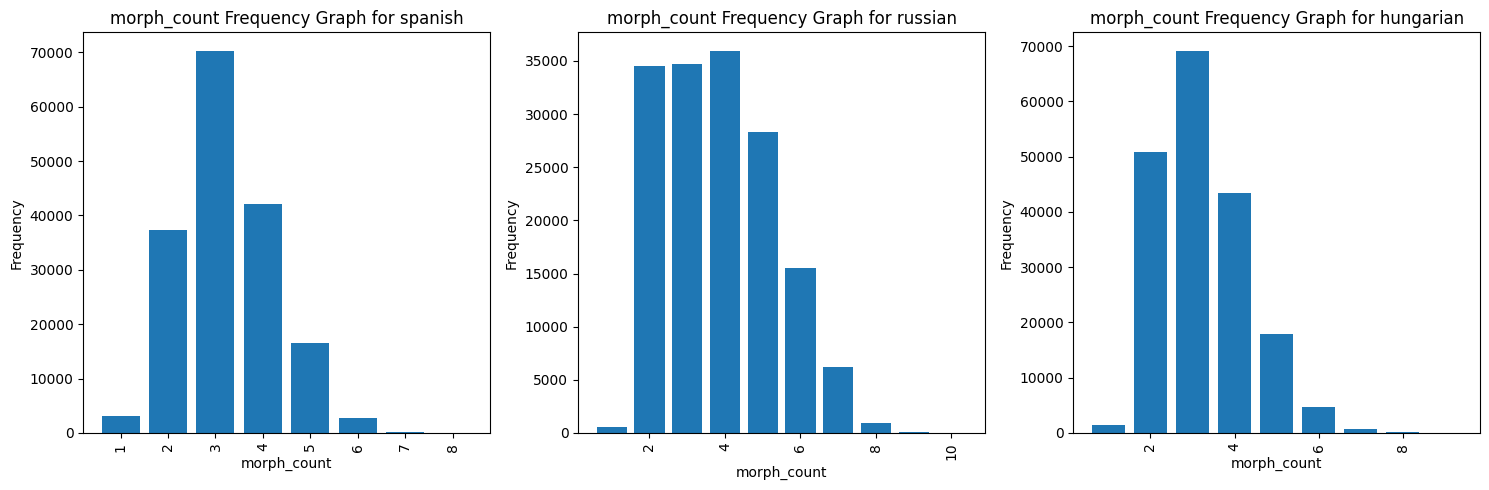

In [59]:
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para que se vean bien horizontalmente
plt.subplot(1,3,1)
plot_histogram(df_spa, "morph_count", "spanish")
plt.subplot(1,3,2)
plot_histogram(df_rus, "morph_count", "russian")
plt.subplot(1,3,3)
plot_histogram(df_hun, "morph_count", "hungarian")
plt.show()

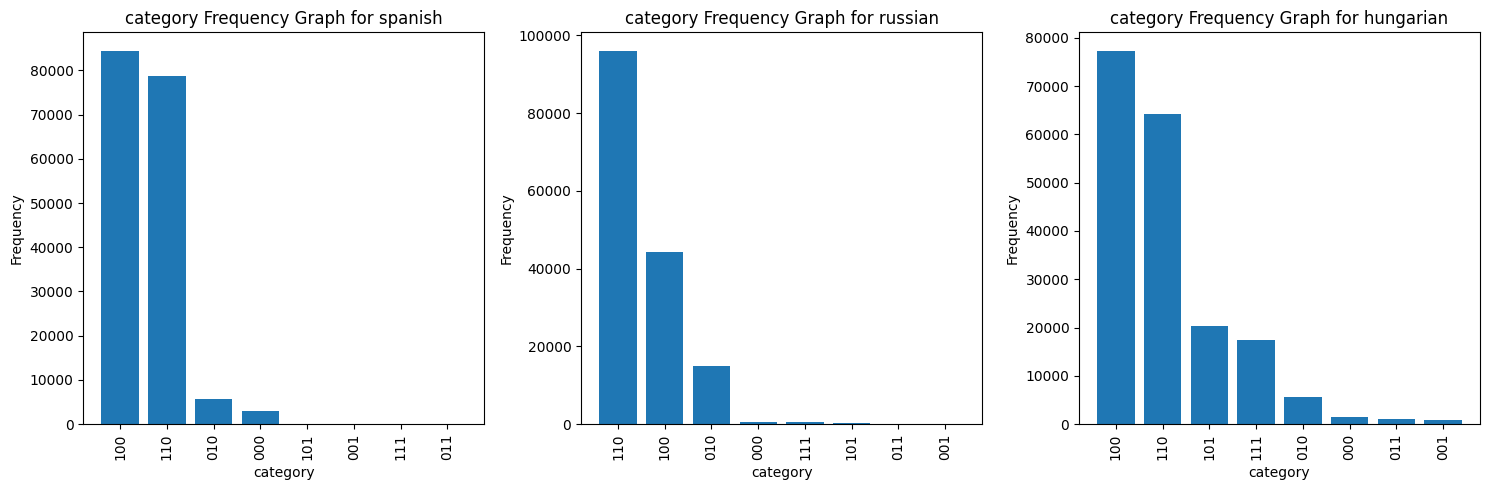

In [60]:
plt.figure(figsize=(15, 5)) # Ajusta el tamaño de la figura para que se vean bien horizontalmente
plt.subplot(1,3,1)
plot_histogram(df_spa, "category", "spanish")
plt.subplot(1,3,2)
plot_histogram(df_rus, "category", "russian")
plt.subplot(1,3,3)
plot_histogram(df_hun, "category", "hungarian")
plt.show()

####4. LENGUAS AGLUTINANTES O AISLANTES?

Según las definiciones las lenguas aislantes tienden a tener morfemas únicos que representan palabras y las palabras más complicadas con aquellas de las uniones de éstas, normalmente cuyo significado es por concepto, es decir cuentan con una gran cantidad de morfemas dado por las palabras, en cambio las aglutinantes presentan uniones de monemas, el significado mas pequeño de cualquier palabra,cada una con un significado, como vemos en las gráficas la cantidad de morfemas o de promedio por palabra afecta en la percepción de que tipo es, considerando que la tendencia en más morfemas por palabra indica aglutinantes, pues sus palabras son formadas por raices a las que se añaden sufijos y prefijos, mientras el español es una bastante aislante, contando con una cantidad promedio de morfemas por palabras menor al de los otros dos.